96.66666666666667
80.0
150.0
60.0


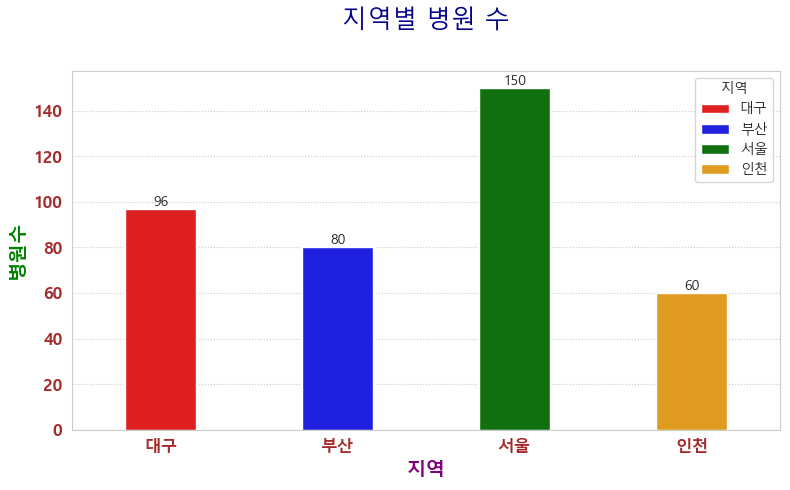

In [20]:

# 반드시 pandas는 import하여 사용
import pandas as pd
import matplotlib.pyplot as plt
# matplotlib기반에서 차트 예쁘게 꾸미는 도구
import seaborn as sns

# 데이터 생성하기
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [100000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 데이터 병합 (지역 기준)
merged = pd.merge(df1, df2, on="지역", how="outer")

# 결측치 처리
# 총인구 없는 값 -> 평균으로 채우기
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# 결과 확인
merged
# -------------------------------------------
# seaborn 그래프 꾸미기
# rcParams 위에 코드 작성해야 함
sns.set_style('whitegrid')  # 배경 스타일 설정
sns.set_palette('pastel')


# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 설정
plt.figure(figsize=(8, 5))

# 차트 배경 + 색상 자동으로 그리드에 빨간색 지정
# plt.style.use('ggplot')

# -------------------------------------------
# 막대그래프 생성
# x축 -> 지역
# y축 -> 병원수
# 세로 막대 넓이 기본값 width = 0.8
# plt.bar(merged["지역"], merged["병원수"], width=0.4)

# 막대 위에 값 표시하기
# 값 표시 안할거면 위에 주석 살리기
# bars = plt.bar(merged["지역"], merged["병원수"], width=0.4, color='skyblue')
# for bar in bars:
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width() / 2,
#         height,
#         f'{int(height)}',
#         ha='center',
#         va='bottom'
#     )
# 그래프 꾸미기
# 글자 세로 회전
# rotation = 90
# 차트와 간격 넓히기
# labelpad = 15
# plt.grid(linestyle='--')   # 점선
plt.grid(linestyle=':')  # 더촘촘한점선
# plt.grid(linestyle='-.')   # 점-선 혼합
ax = sns.barplot(
    data=merged,
    x='지역',
    y="병원수",
    width=0.4,
    # color='skyblue',
    palette=['red', 'blue', 'green', 'orange'],
    hue='지역',
    legend=True
)

plt.title(
    "지역별 병원 수",
    fontsize=18,
    color='darkblue',
    pad=30
)
plt.xlabel(
    "지역",
    fontsize=14,
    fontweight='bold',
    color='purple'
)
plt.ylabel(
    "병원수",
    fontsize=14,
    fontweight='bold',
    color='green'
)
plt.xticks(
    fontsize=12,
    fontweight='bold',
    color='brown'
)
plt.yticks(
    fontsize=12,
    fontweight='bold',
    color='brown'
)
for i in range(len(merged['병원수'])):
    v = merged['병원수'][i]
    print(v)
    ax.text(
        i,
        v,
        int(v),
        ha='center',
        va='bottom'
    )
plt.tight_layout()
# 그래프 이미지 저장
plt.savefig("hospital_chart.png", dpi=300)

# 그래프 출력
plt.show()